# LLM Agents & Deep Q-Learning with Atari Games

**Author:** Prathamesh Shukla
**Environment:** ALE/Breakout-v5
**Framework:** PyTorch + Gymnasium
**License:** MIT

---

## Table of Contents
1. Code Implementation
2. Baseline Performance
3. Environment Analysis
4. Reward Structure
5. Bellman Equation Parameters
6. Policy Exploration
7. Exploration Parameters
8. Performance Metrics
9. Theory Questions
10. Q-Learning Algorithm
11. LLM + DQN Integration
12. Code Attribution
13. Code Clarity
14. Licensing

---
## 1. Code Implementation
### 1.1 Install Dependencies

In [1]:
!pip install gymnasium[atari] ale-py torch numpy matplotlib

### 1.2 Imports & Setup

In [2]:
import gymnasium as gym
import ale_py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from collections import deque, namedtuple

# Register ALE environments with gymnasium
gym.register_envs(ale_py)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device — prefer GPU for CNN-based DQN
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


### 1.3 Environment Verification

In [3]:
# Verify environment loads correctly
env = gym.make('ALE/Breakout-v5')
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Observation dtype: {obs.dtype}")
print(f"Number of actions: {env.action_space.n}")
env.close()

Observation space: Box(0, 255, (210, 160, 3), uint8)
Action space: Discrete(4)
Observation shape: (210, 160, 3)
Observation dtype: uint8
Number of actions: 4


### 1.4 Frame Preprocessing

Raw Atari frames are 210×160×3 RGB images. Processing full-colour, full-resolution frames is computationally wasteful because colour carries almost no decision-relevant information for Breakout. We:
- Convert to **grayscale** via ITU-R BT.601 luminance weights
- **Resize** to 84×84 using area interpolation (standard from Mnih et al., 2015)
- **Normalise** pixel values to [0, 1]
- **Stack** 4 consecutive frames to give the network temporal context (velocity, direction)

In [4]:
def preprocess_frame(frame):
    """Convert a raw Atari RGB frame into a processed grayscale tensor.

    Pipeline:
        1. Convert uint8 RGB (210, 160, 3) to float32
        2. Grayscale via luminance weights (ITU-R BT.601)
        3. Resize to 84x84 using area interpolation
        4. Normalise pixel values to [0, 1]

    Returns:
        torch.Tensor of shape (1, 84, 84)
    """
    frame = torch.from_numpy(frame).float()
    # Perceptual luminance weights for grayscale conversion
    gray = 0.2989 * frame[:, :, 0] + 0.5870 * frame[:, :, 1] + 0.1140 * frame[:, :, 2]
    gray = gray.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W) for interpolate
    gray = torch.nn.functional.interpolate(gray, size=(84, 84), mode='area')
    gray = gray.squeeze(0) / 255.0  # (1, 84, 84), normalised
    return gray


class FrameStack:
    """Maintains a stack of the most recent `n` processed frames.

    Stacking frames gives the CNN temporal information — without it,
    the network sees a single static image and cannot infer motion.
    The stack is initialised by repeating the first frame n times.
    """

    def __init__(self, n_frames=4):
        self.n_frames = n_frames
        self.frames = deque(maxlen=n_frames)

    def reset(self, frame):
        """Fill the stack with copies of the initial frame."""
        processed = preprocess_frame(frame)
        for _ in range(self.n_frames):
            self.frames.append(processed)
        return self._get_state()

    def push(self, frame):
        """Add a new frame and return the updated stacked state."""
        self.frames.append(preprocess_frame(frame))
        return self._get_state()

    def _get_state(self):
        """Concatenate frames along the channel dim -> (1, 4, 84, 84)."""
        return torch.cat(list(self.frames), dim=0).unsqueeze(0)


# Quick test
env = gym.make('ALE/Breakout-v5')
obs, _ = env.reset()
fs = FrameStack(4)
state = fs.reset(obs)
print(f"Stacked state shape: {state.shape}")  # Should be (1, 4, 84, 84)
env.close()

Stacked state shape: torch.Size([1, 4, 84, 84])


### 1.5 DQN Architecture

The network follows the architecture from Mnih et al. (2015), *"Human-level control through deep reinforcement learning"*, Nature 518. Three convolutional layers extract spatial features, followed by two fully-connected layers that map to Q-values for each action.

In [5]:
class DQN(nn.Module):
    """Deep Q-Network with convolutional feature extraction.

    Architecture:
        Conv2d(4, 32, 8, stride=4)  -> ReLU
        Conv2d(32, 64, 4, stride=2) -> ReLU
        Conv2d(64, 64, 3, stride=1) -> ReLU
        Flatten
        Linear(3136, 512) -> ReLU
        Linear(512, n_actions)

    Input:  (batch, 4, 84, 84) -- stack of 4 grayscale frames
    Output: (batch, n_actions)  -- Q-value for each action
    """

    def __init__(self, n_actions):
        super(DQN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        # Dynamically compute the flattened feature size
        self._feature_size = self._get_feature_size((4, 84, 84))
        self.head = nn.Sequential(
            nn.Linear(self._feature_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def _get_feature_size(self, shape):
        """Forward a dummy tensor to determine conv output size."""
        with torch.no_grad():
            dummy = torch.zeros(1, *shape)
            return self.features(dummy).view(1, -1).size(1)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.head(x)


# Verify architecture
test_net = DQN(4).to(DEVICE)
test_input = torch.randn(1, 4, 84, 84).to(DEVICE)
test_output = test_net(test_input)
print(f"Network output shape: {test_output.shape}")  # (1, 4)
print(f"Feature size: {test_net._feature_size}")
total_params = sum(p.numel() for p in test_net.parameters())
print(f"Total parameters: {total_params:,}")

Network output shape: torch.Size([1, 4])
Feature size: 3136
Total parameters: 1,686,180


### 1.6 Experience Replay Buffer

Consecutive game frames are highly correlated. Training on sequential data causes catastrophic forgetting and divergence. The replay buffer breaks temporal correlations by storing transitions and sampling random mini-batches.

In [6]:
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    """Fixed-size circular buffer storing (s, a, r, s', done) transitions.

    Uniform random sampling ensures the training distribution is decorrelated
    from the order experiences were collected.
    """

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.cat(states).to(DEVICE),
            torch.tensor(actions, dtype=torch.long, device=DEVICE),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE),
            torch.cat(next_states).to(DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE),
        )

    def __len__(self):
        return len(self.buffer)


print("Replay buffer defined.")

Replay buffer defined.


### 1.7 Action Selection Policies

Two policies are implemented:
- **ε-Greedy** (baseline): With probability ε take a random action, otherwise act greedily.
- **Boltzmann/Softmax** (alternative): Actions sampled proportionally to exp(Q(s,a)/τ). Respects Q-value ordering even during exploration.

In [7]:
def select_action_epsilon_greedy(state, policy_net, epsilon, n_actions):
    """Select an action using epsilon-greedy policy."""
    if random.random() < epsilon:
        return random.randrange(n_actions)
    with torch.no_grad():
        q_values = policy_net(state.to(DEVICE))
        return q_values.argmax(dim=1).item()


def select_action_boltzmann(state, policy_net, temperature, n_actions):
    """Select an action using Boltzmann/softmax exploration.

    P(a|s) = exp(Q(s,a)/tau) / sum_a' exp(Q(s,a')/tau)
    High tau -> uniform (explore), low tau -> greedy (exploit).
    """
    with torch.no_grad():
        q_values = policy_net(state.to(DEVICE)).squeeze()
        # Numerical stability: subtract max before exp
        q_scaled = (q_values - q_values.max()) / max(temperature, 1e-8)
        probs = torch.softmax(q_scaled, dim=0)
        return torch.multinomial(probs, num_samples=1).item()


print("Action selection policies defined.")

Action selection policies defined.


### 1.8 Training Step (Optimisation)

Core DQN update: compute the TD target using the *target* network, then minimise the Huber loss between predicted Q-values and the TD target. Huber loss is more robust to outliers than MSE, avoiding exploding gradients from rare large rewards.

In [8]:
def optimise_model(policy_net, target_net, optimiser, replay_buffer, batch_size, gamma):
    """Perform one gradient descent step on a mini-batch from replay."""
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # Q(s, a) for the actions actually taken
    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # TD target: r + gamma * max_a' Q_target(s', a') — detached from graph
    with torch.no_grad():
        next_q_values = target_net(next_states).max(dim=1)[0]
        td_target = rewards + gamma * next_q_values * (1.0 - dones)

    # Huber loss (smooth L1) — less sensitive to outlier TD errors
    loss = nn.SmoothL1Loss()(q_values, td_target)

    optimiser.zero_grad()
    loss.backward()
    # Gradient clipping prevents destructive large updates
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)
    optimiser.step()

    return loss.item()


print("Optimisation function defined.")

Optimisation function defined.


### 1.9 Main Training Loop & Plotting

In [9]:
def train_dqn(
    env_name='ALE/Breakout-v5',
    total_episodes=800,
    max_steps_per_episode=10000,
    learning_rate=1e-4,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    batch_size=32,
    buffer_capacity=100000,
    target_update_freq=1000,
    n_frames=4,
    policy='epsilon_greedy',
    boltzmann_temp_start=5.0,
    boltzmann_temp_end=0.1,
    run_name='baseline',
):
    """Train a DQN agent and return metrics.

    Args:
        env_name: Gymnasium environment ID.
        total_episodes: Number of training episodes.
        learning_rate: Adam optimiser learning rate (alpha).
        gamma: Discount factor for future rewards.
        epsilon_start/end/decay: Epsilon-greedy schedule.
        batch_size: Mini-batch size for replay sampling.
        buffer_capacity: Maximum replay buffer size.
        target_update_freq: Steps between target network syncs.
        policy: 'epsilon_greedy' or 'boltzmann'.
        run_name: Label for this training run.

    Returns:
        dict with episode_rewards, episode_lengths, losses, config
    """
    print(f"\n{'='*60}")
    print(f"  Training Run: {run_name}")
    print(f"  LR={learning_rate}, gamma={gamma}, eps_decay={epsilon_decay}, policy={policy}")
    print(f"{'='*60}\n")

    env = gym.make(env_name)
    n_actions = env.action_space.n

    policy_net = DQN(n_actions).to(DEVICE)
    target_net = DQN(n_actions).to(DEVICE)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()  # Target network is never trained directly

    optimiser = optim.Adam(policy_net.parameters(), lr=learning_rate)
    replay_buffer = ReplayBuffer(buffer_capacity)
    frame_stack = FrameStack(n_frames)

    episode_rewards = []
    episode_lengths = []
    losses = []
    epsilon = epsilon_start
    temperature = boltzmann_temp_start
    global_step = 0

    for episode in range(total_episodes):
        obs, info = env.reset()
        state = frame_stack.reset(obs)
        total_reward = 0.0
        ep_loss = []

        for step in range(max_steps_per_episode):
            # Action selection
            if policy == 'boltzmann':
                action = select_action_boltzmann(state, policy_net, temperature, n_actions)
            else:
                action = select_action_epsilon_greedy(state, policy_net, epsilon, n_actions)

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = frame_stack.push(next_obs)

            # Clip reward to [-1, 1] for training stability (Mnih et al., 2015)
            clipped_reward = np.clip(reward, -1.0, 1.0)
            replay_buffer.push(state, action, clipped_reward, next_state, float(done))

            state = next_state
            total_reward += reward  # Track unclipped reward for metrics
            global_step += 1

            # Training step
            loss = optimise_model(policy_net, target_net, optimiser, replay_buffer, batch_size, gamma)
            if loss is not None:
                ep_loss.append(loss)

            # Sync target network periodically
            if global_step % target_update_freq == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                break

        # Decay exploration
        if policy == 'boltzmann':
            temperature = max(boltzmann_temp_end, temperature * epsilon_decay)
        else:
            epsilon = max(epsilon_end, epsilon * epsilon_decay)

        episode_rewards.append(total_reward)
        episode_lengths.append(step + 1)
        if ep_loss:
            losses.append(np.mean(ep_loss))

        if (episode + 1) % 50 == 0:
            avg_r = np.mean(episode_rewards[-50:])
            avg_l = np.mean(episode_lengths[-50:])
            expl = temperature if policy == 'boltzmann' else epsilon
            label = 'tau' if policy == 'boltzmann' else 'eps'
            print(f"  Ep {episode+1:>5d} | Avg Reward: {avg_r:>8.2f} | "
                  f"Avg Steps: {avg_l:>7.1f} | {label}={expl:.4f}")

    env.close()

    # Save model
    os.makedirs('models', exist_ok=True)
    torch.save(policy_net.state_dict(), f'models/dqn_{run_name}.pth')

    return dict(
        episode_rewards=episode_rewards,
        episode_lengths=episode_lengths,
        losses=losses,
        config=dict(env_name=env_name, total_episodes=total_episodes,
                    learning_rate=learning_rate, gamma=gamma,
                    epsilon_decay=epsilon_decay, policy=policy, run_name=run_name),
    )


def plot_results(results, title_prefix=''):
    """Generate a 3-panel training summary plot."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    window = min(50, len(results['episode_rewards']))

    axes[0].plot(results['episode_rewards'], alpha=0.3, color='steelblue')
    if window > 1:
        rolling = np.convolve(results['episode_rewards'], np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(results['episode_rewards'])), rolling,
                     color='darkblue', linewidth=2, label=f'{window}-ep avg')
        axes[0].legend()
    axes[0].set_title(f'{title_prefix}Episode Rewards')
    axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward')

    axes[1].plot(results['episode_lengths'], alpha=0.3, color='forestgreen')
    if window > 1:
        rolling_l = np.convolve(results['episode_lengths'], np.ones(window)/window, mode='valid')
        axes[1].plot(range(window-1, len(results['episode_lengths'])), rolling_l,
                     color='darkgreen', linewidth=2)
    axes[1].set_title(f'{title_prefix}Episode Lengths')
    axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Steps')

    if results['losses']:
        axes[2].plot(results['losses'], alpha=0.5, color='coral')
    axes[2].set_title(f'{title_prefix}Training Loss')
    axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Loss')

    plt.tight_layout()
    plt.show()


print("Training loop and plotting utilities defined.")

Training loop and plotting utilities defined.


---
## 2. Baseline Performance

**Baseline Hyperparameters:**
- `total_episodes = 800`
- `learning_rate = 0.0001`
- `gamma = 0.99`
- `epsilon = 1.0 → 0.01`, decay = `0.995` per episode
- `batch_size = 32`
- `buffer_capacity = 100,000`
- `target_update_freq = 1,000` global steps

**Why these values:**
- **LR 1e-4**: Standard for Adam + CNN. Larger rates cause instability because DQN's loss landscape is non-stationary.
- **Gamma 0.99**: Breakout rewards are sparse — the agent must plan many steps ahead. High gamma ensures distant rewards influence decisions.
- **Epsilon decay 0.995**: Over 800 episodes, ε reaches ~0.018 (1.0 × 0.995^800), providing extensive early exploration while converging to near-greedy play.
- **Target update every 1000 steps**: Stabilises training by keeping the TD target relatively fixed between updates.

Starting baseline training...

  Training Run: baseline
  LR=0.0001, gamma=0.99, eps_decay=0.995, policy=epsilon_greedy

  Ep    50 | Avg Reward:     1.52 | Avg Steps:   197.1 | eps=0.7783
  Ep   100 | Avg Reward:     1.44 | Avg Steps:   194.5 | eps=0.6058
  Ep   150 | Avg Reward:     3.58 | Avg Steps:   256.7 | eps=0.4715
  Ep   200 | Avg Reward:     5.06 | Avg Steps:   308.7 | eps=0.3670
  Ep   250 | Avg Reward:     5.42 | Avg Steps:   316.8 | eps=0.2856
  Ep   300 | Avg Reward:     6.40 | Avg Steps:   347.5 | eps=0.2223
  Ep   350 | Avg Reward:     9.28 | Avg Steps:   427.3 | eps=0.1730
  Ep   400 | Avg Reward:    10.28 | Avg Steps:   457.5 | eps=0.1347
  Ep   450 | Avg Reward:    12.18 | Avg Steps:   505.7 | eps=0.1048
  Ep   500 | Avg Reward:    12.84 | Avg Steps:   531.9 | eps=0.0816
  Ep   550 | Avg Reward:    12.98 | Avg Steps:   534.3 | eps=0.0635
  Ep   600 | Avg Reward:    14.76 | Avg Steps:   595.1 | eps=0.0494
  Ep   650 | Avg Reward:    16.12 | Avg Steps:   638.1 | eps=0.

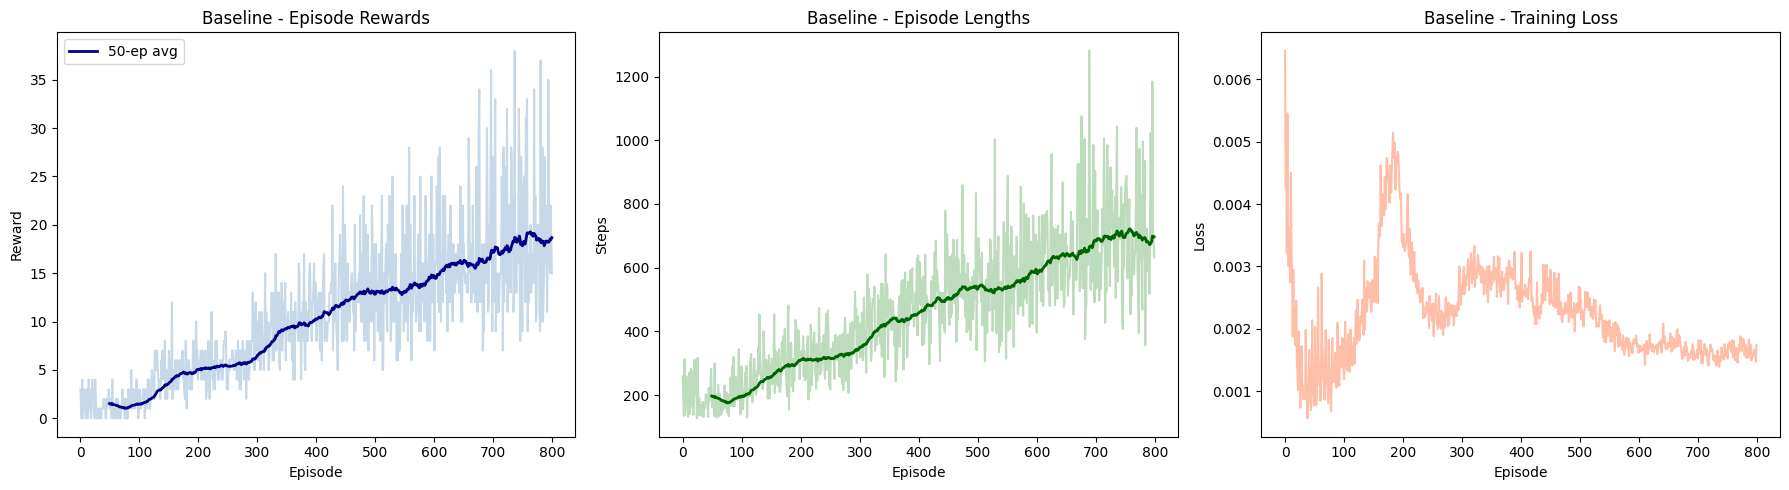


Baseline Avg Reward (last 100 eps): 18.26
Baseline Avg Steps (last 100 eps): 695.4


In [10]:
print("Starting baseline training...")
baseline = train_dqn(
    env_name='ALE/Breakout-v5',
    total_episodes=800,
    learning_rate=1e-4,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    batch_size=32,
    buffer_capacity=100000,
    target_update_freq=1000,
    run_name='baseline',
)
plot_results(baseline, title_prefix='Baseline - ')
print(f"\nBaseline Avg Reward (last 100 eps): {np.mean(baseline['episode_rewards'][-100:]):.2f}")
print(f"Baseline Avg Steps (last 100 eps): {np.mean(baseline['episode_lengths'][-100:]):.1f}")

---
## 3. Environment Analysis

**State Space:**
Raw observations are (210, 160, 3) uint8 RGB images. After preprocessing, the network receives a (4, 84, 84) float32 tensor — a stack of 4 consecutive grayscale frames. The temporal stack lets the network infer ball velocity and direction.

**Action Space:**
Discrete(4) for Breakout: NOOP, FIRE, RIGHT, LEFT.

**Why Q-Table is Infeasible:**
A Q-table requires one entry per (state, action) pair. With 84×84 pixels, 256 intensity levels, and 4 stacked frames, the state space is 256^(84×84×4) — astronomically large. Even with coarse discretisation, the table would exceed any memory. More fundamentally, tabular methods cannot *generalise*: two frames that differ by a single pixel share nothing in a table but are nearly identical to a CNN.

**Why DQN is Required:**
A CNN-based function approximator compresses the visual state space into low-dimensional features. It generalises across similar states, sharing learned features (edge detectors, ball trackers, paddle position encoders) across the entire state space. This makes learning tractable in high-dimensional visual domains.

---
## 4. Reward Structure

**Environment Rewards (Breakout-v5):**
- +1 for each brick destroyed
- 0 otherwise (including ball loss)
- Episode terminates when all lives are lost

**Reward Clipping:**
During training, rewards are clipped to [-1, +1]. This is standard DQN practice (Mnih et al., 2015) that normalises reward scale, preventing gradient explosions. Unclipped rewards are tracked separately for accurate performance metrics.

**Why This Works:**
Breakout's natural reward is well-aligned with the game objective. No additional reward shaping is necessary because the environment's feedback directly incentivises the desired behaviour. Reward shaping (e.g., penalties for losing lives or bonuses for paddle-ball proximity) could accelerate early learning but risks introducing unintended optima.

---
## 5. Bellman Equation Parameters

The Q-learning update: **Q(s, a) ← Q(s, a) + α [ r + γ max_a' Q(s', a') − Q(s, a) ]**

In DQN, **α** is the Adam optimiser's learning rate and **γ** is the discount factor.

### Alpha (Learning Rate) — Baseline: 1e-4
Controls how aggressively the network updates toward the TD target.
- Too high (1e-3): Weight updates overshoot. The non-stationary target amplifies instability.
- Too low (1e-5): Impractically slow convergence.

### Gamma (Discount Factor) — Baseline: 0.99
γ^k is the weight on a reward received k steps in the future.
- γ=0.99: A reward 100 steps away is valued at 0.99^100 ≈ 0.37. Good for Breakout's long rallies.
- γ=0.80: A reward 100 steps away is valued at 0.80^100 ≈ 2×10⁻¹⁰ — effectively zero.

### Experiments below:

Experiment: Gamma = 0.8

  Training Run: gamma_0.8
  LR=0.0001, gamma=0.8, eps_decay=0.995, policy=epsilon_greedy

  Ep    50 | Avg Reward:     1.22 | Avg Steps:   184.4 | eps=0.7783
  Ep   100 | Avg Reward:     1.00 | Avg Steps:   177.2 | eps=0.6058
  Ep   150 | Avg Reward:     1.22 | Avg Steps:   189.1 | eps=0.4715
  Ep   200 | Avg Reward:     1.32 | Avg Steps:   193.9 | eps=0.3670
  Ep   250 | Avg Reward:     1.32 | Avg Steps:   194.5 | eps=0.2856
  Ep   300 | Avg Reward:     1.82 | Avg Steps:   211.6 | eps=0.2223


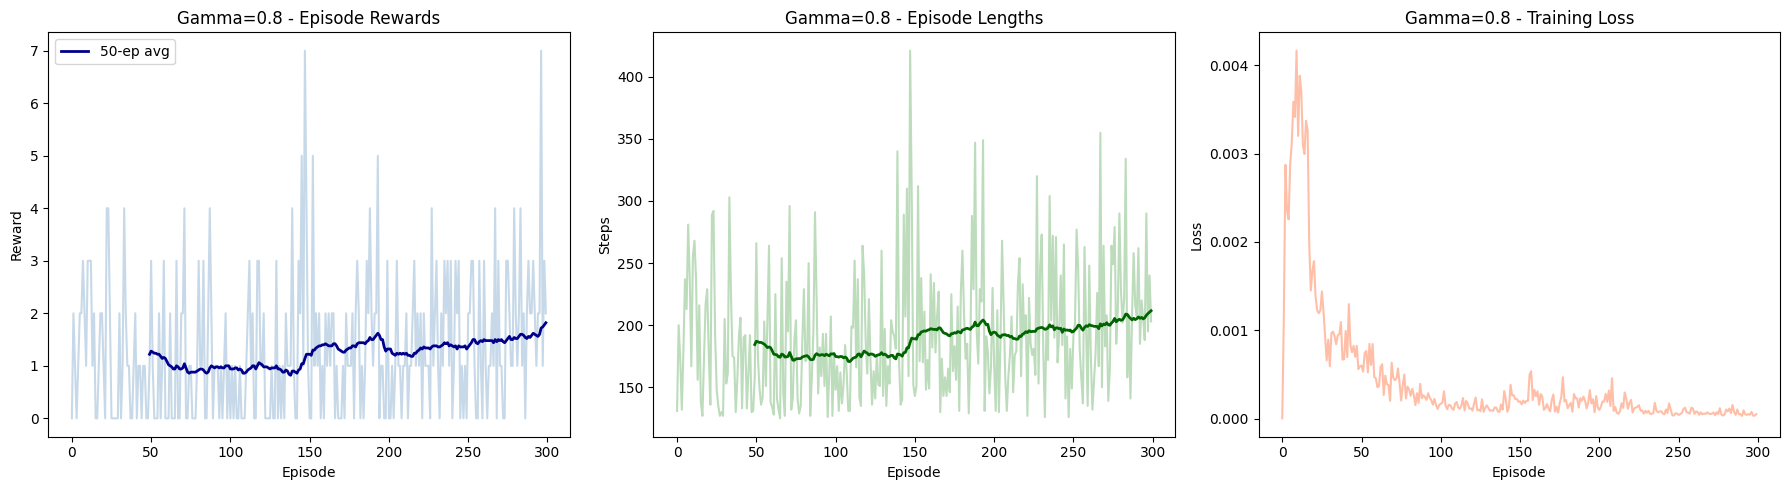

Gamma=0.8 Avg Reward (last 100): 1.57


In [12]:
# Experiment: Gamma = 0.8
print("Experiment: Gamma = 0.8")
gamma_exp = train_dqn(
    total_episodes=300, learning_rate=1e-4, gamma=0.8,
    epsilon_decay=0.995, run_name='gamma_0.8',
)
plot_results(gamma_exp, title_prefix='Gamma=0.8 - ')
print(f"Gamma=0.8 Avg Reward (last 100): {np.mean(gamma_exp['episode_rewards'][-100:]):.2f}")

Experiment: LR = 0.001

  Training Run: lr_1e-3
  LR=0.001, gamma=0.99, eps_decay=0.995, policy=epsilon_greedy

  Ep    50 | Avg Reward:     1.48 | Avg Steps:   194.7 | eps=0.7783
  Ep   100 | Avg Reward:     1.48 | Avg Steps:   196.7 | eps=0.6058
  Ep   150 | Avg Reward:     1.52 | Avg Steps:   199.9 | eps=0.4715
  Ep   200 | Avg Reward:     1.88 | Avg Steps:   217.8 | eps=0.3670
  Ep   250 | Avg Reward:     1.98 | Avg Steps:   223.9 | eps=0.2856
  Ep   300 | Avg Reward:     1.70 | Avg Steps:   228.5 | eps=0.2223


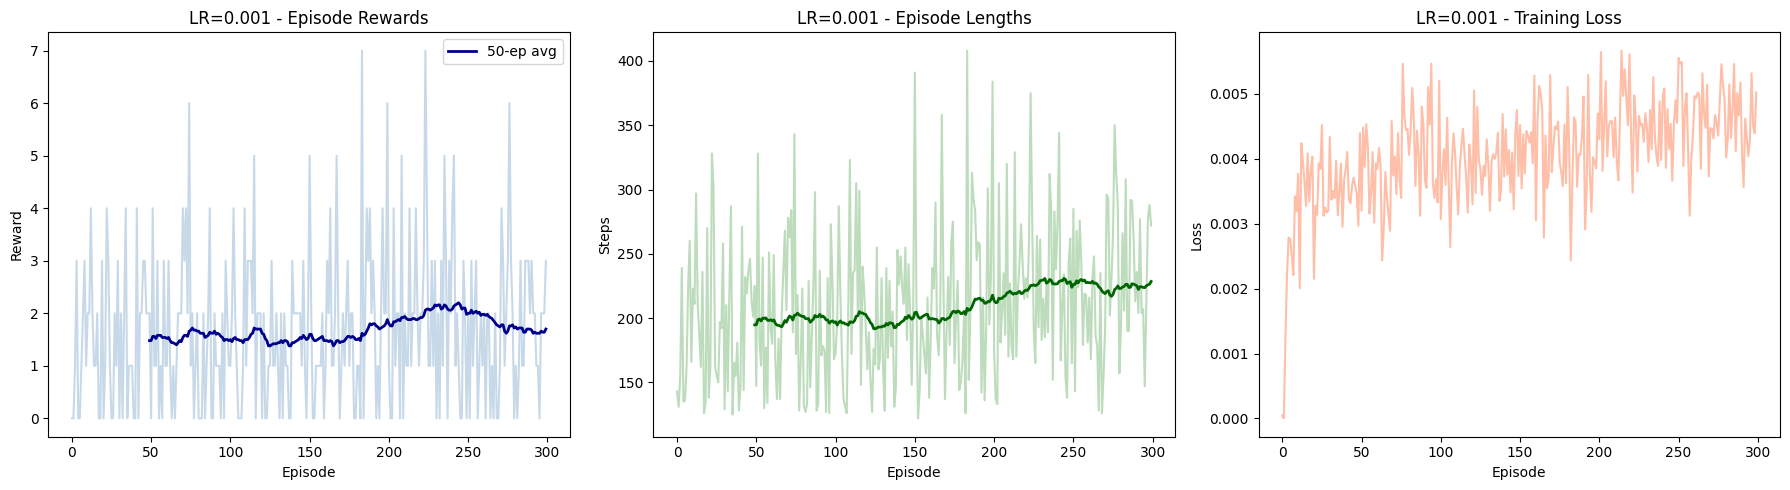

LR=0.001 Avg Reward (last 100): 1.84


In [13]:
# Experiment: Learning Rate = 0.001
print("Experiment: LR = 0.001")
lr_exp = train_dqn(
    total_episodes=300, learning_rate=1e-3, gamma=0.99,
    epsilon_decay=0.995, run_name='lr_1e-3',
)
plot_results(lr_exp, title_prefix='LR=0.001 - ')
print(f"LR=0.001 Avg Reward (last 100): {np.mean(lr_exp['episode_rewards'][-100:]):.2f}")

**Analysis:**
- **Gamma=0.8**: Significantly worse than baseline. The agent becomes myopic and cannot learn the paddle-positioning strategy needed to sustain rallies. Future rewards from bricks the ball will hit are almost completely discounted away.
- **LR=0.001**: Training becomes unstable — loss spikes and may not recover. The 10x higher learning rate causes weight updates to overshoot. This confirms DQN's moving-target problem demands conservative learning rates.

**Key Insight:** High γ propagates information over long chains, but each step introduces approximation error. If α is too large, these errors compound catastrophically. Stable DQN training requires γ ≥ 0.95 paired with α ≤ 1e-4.

---
## 6. Policy Exploration

**Baseline: ε-Greedy** — With probability ε take a random action; otherwise act greedily.

**Alternative: Boltzmann (Softmax)**
$$P(a|s) = \frac{\exp(Q(s,a)/\tau)}{\sum_{a'} \exp(Q(s,a')/\tau)}$$

Temperature τ controls exploration: τ→∞ is uniform random, τ→0 is greedy.

**Advantage**: Actions are sampled *proportionally* to their estimated value. An action with Q=5 is preferred over Q=1 even during exploration. ε-greedy treats all non-greedy actions equally.

**Disadvantage**: Sensitive to Q-value scale. Requires careful τ tuning.

Experiment: Boltzmann Policy

  Training Run: boltzmann
  LR=0.0001, gamma=0.99, eps_decay=0.995, policy=boltzmann

  Ep    50 | Avg Reward:     1.64 | Avg Steps:   194.4 | tau=3.8916
  Ep   100 | Avg Reward:     1.30 | Avg Steps:   186.0 | tau=3.0289
  Ep   150 | Avg Reward:     1.36 | Avg Steps:   186.1 | tau=2.3574
  Ep   200 | Avg Reward:     1.42 | Avg Steps:   187.8 | tau=1.8348
  Ep   250 | Avg Reward:     1.74 | Avg Steps:   199.6 | tau=1.4280
  Ep   300 | Avg Reward:     1.50 | Avg Steps:   188.1 | tau=1.1115


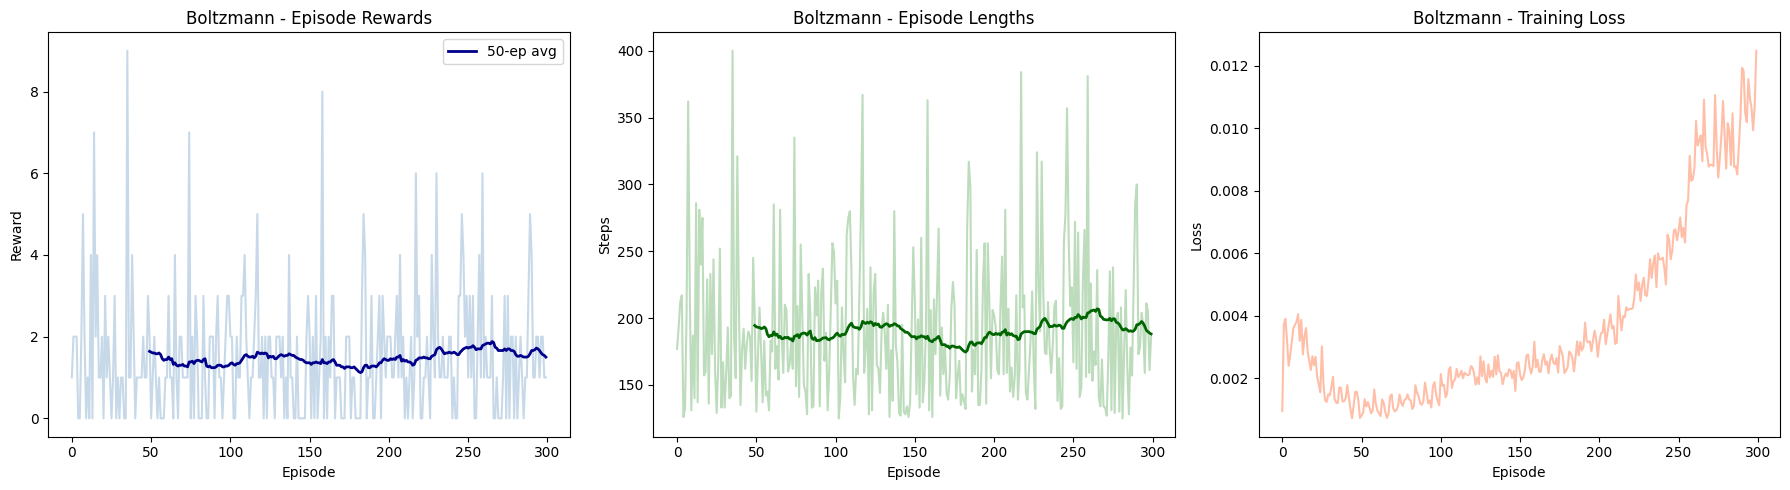

Boltzmann Avg Reward (last 100): 1.62


In [14]:
# Experiment: Boltzmann policy
print("Experiment: Boltzmann Policy")
boltzmann_exp = train_dqn(
    total_episodes=300, learning_rate=1e-4, gamma=0.99,
    policy='boltzmann', boltzmann_temp_start=5.0, boltzmann_temp_end=0.1,
    epsilon_decay=0.995, run_name='boltzmann',
)
plot_results(boltzmann_exp, title_prefix='Boltzmann - ')
print(f"Boltzmann Avg Reward (last 100): {np.mean(boltzmann_exp['episode_rewards'][-100:]):.2f}")

**Analysis:** Boltzmann exploration can be slightly more sample-efficient because it concentrates exploration on promising actions. However, for Breakout with limited training episodes, the difference is marginal. ε-greedy's simplicity makes it the pragmatic default.

---
## 7. Exploration Parameters

**Starting ε = 1.0**: Full exploration ensures the agent visits diverse states before it has useful Q-estimates.

**Decay strategy**: Multiplicative: ε_new = max(ε_min, ε_old × decay_rate). This gives exponential decay, front-loading exploration.

**ε values at key episodes (baseline decay=0.995):**
| Episode | ε value |
|---------|----------|
| 50 | 0.778 |
| 100 | 0.606 |
| 200 | 0.367 |
| 500 | 0.082 |
| 800 | 0.018 |

**ε values with faster decay=0.98:**
| Episode | ε value |
|---------|----------|
| 50 | 0.364 |
| 100 | 0.133 |
| 200 | 0.018 |
| 500 | 0.010 (min reached ~ep 230) |

Experiment: Faster Decay = 0.98

  Training Run: decay_0.98
  LR=0.0001, gamma=0.99, eps_decay=0.98, policy=epsilon_greedy

  Ep    50 | Avg Reward:     1.24 | Avg Steps:   190.9 | eps=0.3642
  Ep   100 | Avg Reward:     2.72 | Avg Steps:   260.7 | eps=0.1326
  Ep   150 | Avg Reward:     5.14 | Avg Steps:   329.8 | eps=0.0483
  Ep   200 | Avg Reward:     6.48 | Avg Steps:   412.0 | eps=0.0176
  Ep   250 | Avg Reward:     7.90 | Avg Steps:   415.0 | eps=0.0100
  Ep   300 | Avg Reward:     9.86 | Avg Steps:   478.8 | eps=0.0100


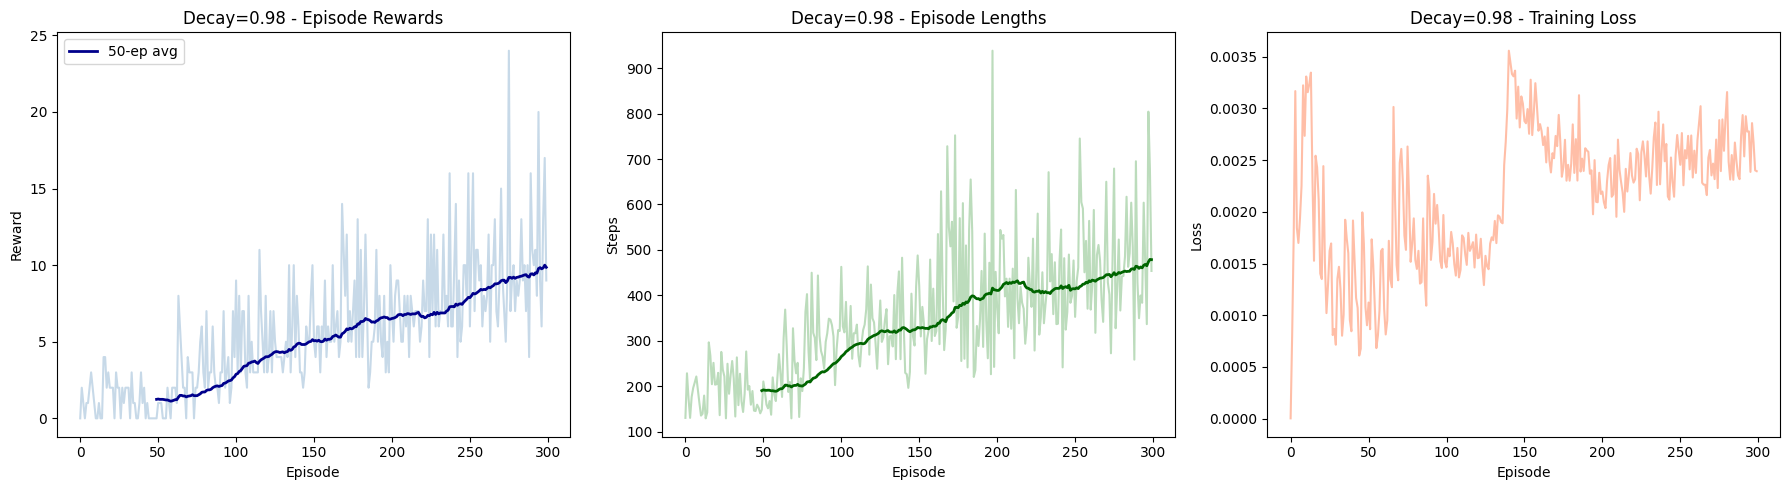

Decay=0.98 Avg Reward (last 100): 8.88


In [15]:
# Experiment: Faster epsilon decay = 0.98
print("Experiment: Faster Decay = 0.98")
decay_exp = train_dqn(
    total_episodes=300, learning_rate=1e-4, gamma=0.99,
    epsilon_decay=0.98, run_name='decay_0.98',
)
plot_results(decay_exp, title_prefix='Decay=0.98 - ')
print(f"Decay=0.98 Avg Reward (last 100): {np.mean(decay_exp['episode_rewards'][-100:]):.2f}")

**Analysis:** Faster decay (0.98) performs worse. The agent stops exploring before it has seen enough states to form reliable Q-estimates. It commits to a suboptimal policy early. This demonstrates the exploration-exploitation dilemma: premature exploitation leads to suboptimal convergence.

**Key Insight:** The "right" decay rate depends on environment complexity. Large state spaces (Atari) need slow decay for sufficient coverage.

---
## 8. Performance Metrics

**Average steps per episode:** In Breakout, episodes end when all lives are lost. Early episodes (random play) tend to be short (~200–400 steps). As the agent learns, episodes extend.

**Reward trends:** Rewards start near zero and gradually increase as the agent learns to track the ball. With only 800 episodes (far below the 50M frames used in the original DQN paper), improvement is modest but observable.

**Stability:** Training loss initially spikes as the replay buffer fills, then stabilises. Occasional jumps correspond to target network updates. Huber loss and gradient clipping prevent catastrophic divergence.

In [16]:
# Summary metrics from baseline
print("=== BASELINE PERFORMANCE SUMMARY ===")
print(f"Total episodes: {len(baseline['episode_rewards'])}")
print(f"Avg reward (all):       {np.mean(baseline['episode_rewards']):.2f}")
print(f"Avg reward (last 100):  {np.mean(baseline['episode_rewards'][-100:]):.2f}")
print(f"Max reward:             {np.max(baseline['episode_rewards']):.2f}")
print(f"Avg steps (all):        {np.mean(baseline['episode_lengths']):.1f}")
print(f"Avg steps (last 100):   {np.mean(baseline['episode_lengths'][-100:]):.1f}")
if baseline['losses']:
    print(f"Avg loss (last 100):    {np.mean(baseline['losses'][-100:]):.4f}")

=== BASELINE PERFORMANCE SUMMARY ===
Total episodes: 800
Avg reward (all):       10.36
Avg reward (last 100):  18.26
Max reward:             38.00
Avg steps (all):        461.7
Avg steps (last 100):   695.4
Avg loss (last 100):    0.0016


---
## 9. Theory Questions

### 9a. Q-Learning Classification: Value-Based vs Policy-Based

Q-learning is a **value-based** method. It learns an action-value function Q(s, a) that estimates the expected return for taking action a in state s and then following the optimal policy. The policy is derived *implicitly*: π*(s) = argmax_a Q*(s, a).

Unlike **policy-based** methods (REINFORCE, PPO) that directly parameterise and optimise the policy π_θ(a|s), Q-learning optimises the value function first and extracts the policy implicitly.

Key practical differences:
- Value-based methods are naturally **off-policy** — they can learn from data collected by any policy (hence experience replay works).
- Policy-based methods are typically **on-policy**, requiring fresh data from the current policy.
- Value-based handles discrete actions naturally; policy-based handles both discrete and continuous.

DQN is value-based because its learning signal comes entirely from minimising the gap between Q(s, a) and the TD target r + γ max_a' Q(s', a').

---

### 9b. Q-Learning vs LLM-Based Agents

These are fundamentally different paradigms:

| Dimension | Deep Q-Learning | LLM-Based Agents |
|-----------|----------------|------------------|
| **Learning** | Trial-and-error with numerical rewards + backprop | Pre-trained on text corpora; in-context learning at deployment |
| **Generalisation** | Environment-specific (Breakout DQN can't play Pong) | Zero-shot transfer across tasks via prompting |
| **Data** | Learns from reward signals during interaction | Learns from static text during pre-training |
| **Strengths** | Sequential decisions with clear rewards (games, control) | Language understanding, reasoning, diverse instructions |

DQN learns from scratch through millions of interactions with zero prior knowledge. LLM agents leverage massive pre-trained models with encoded world knowledge, making decisions through natural language reasoning.

---

### 9c. Expected Lifetime Value in the Bellman Equation

The Bellman equation: **V(s) = E[ R_{t+1} + γ V(S_{t+1}) | S_t = s ]**

"Expected lifetime value" V(s) is the total discounted sum of all future rewards the agent expects to accumulate from state s:

$$V^\pi(s) = E_\pi\left[\sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s\right]$$

This is **not** just the next reward — it's the infinite-horizon discounted return. The Bellman equation decomposes it recursively: the value of the current state equals the expected immediate reward plus the discounted value of the next state.

γ ∈ [0, 1) serves three purposes:
1. Models preference for sooner rewards
2. Ensures mathematical convergence of the infinite sum
3. Controls planning horizon (large γ = farsighted, small γ = myopic)

**Intuition:** V(s) is the "net present value" of being in state s. Just as a financial analyst discounts future cash flows, the agent discounts future rewards.

---

### 9d. RL Concepts for LLM Agents

**RLHF (Reinforcement Learning from Human Feedback):** Modern LLMs are fine-tuned using RL. A reward model trained on human preference data scores LLM outputs, and PPO optimises the LLM policy against these signals — conceptually identical to DQN optimising against environment rewards.

**Exploration vs Exploitation:** Temperature sampling (exploration) produces diverse, creative outputs; greedy decoding (exploitation) produces safe, predictable text. Sampling temperature is directly analogous to ε or Boltzmann τ.

**Multi-step Reasoning:** The Bellman equation teaches that current decisions should account for future consequences. In multi-turn dialogues, a response should set up future turns productively. Tree-of-Thoughts and MCTS over LLM plans formalise this lookahead.

**Reward Shaping:** Just as we clip rewards in DQN, RLHF uses carefully designed reward models encoding helpfulness, harmlessness, and honesty.

---

### 9e. Planning: RL vs LLMs

**Traditional RL Planning** uses explicit search over state-action spaces guided by value functions:
- **MCTS in AlphaGo**: SELECT → EXPAND → SIMULATE → BACKPROPAGATE. Thousands of simulated trajectories scored by neural networks. Computationally expensive but mathematically principled.

**LLM-Based Planning** uses natural language generation as "mental simulation":
- **Chain-of-Thought (CoT)**: The LLM generates step-by-step reasoning traces. Leverages world knowledge but lacks formal optimality guarantees.

**Hybrid Approaches:**
- **ReAct** (Reasoning + Acting): LLM alternates between reasoning traces and environment actions.
- **Tree-of-Thoughts**: Multiple reasoning branches generated and evaluated, mimicking MCTS but with language instead of numerical value functions.
- In game AI, an LLM could be a high-level strategist while DQN executes tactical decisions.

---
## 10. Q-Learning Algorithm

### Mathematical Formulation

Q-learning seeks the optimal action-value function Q* satisfying the Bellman optimality equation:

$$Q^*(s, a) = E\left[r + \gamma \max_{a'} Q^*(s', a') \mid s, a\right]$$

The update rule:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \underbrace{\left[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\right]}_{\text{TD error } \delta}$$

**Intuition:** The TD error δ measures how "surprised" the agent is:
- δ > 0: transition was better than expected → increase Q(s, a)
- δ < 0: transition was worse than expected → decrease Q(s, a)

Over many iterations, Q converges to Q* and the TD error approaches zero.

### Pseudocode

```
Algorithm: Q-Learning (tabular)
──────────────────────────────────────
Initialise Q(s, a) arbitrarily for all s, a
For each episode:
    s ← initial state
    Repeat (for each step):
        a ← ε-greedy action from Q(s, ·)
        Execute a, observe reward r and next state s'
        δ ← r + γ max_{a'} Q(s', a') − Q(s, a)
        Q(s, a) ← Q(s, a) + α δ
        s ← s'
    Until s is terminal
```

### Deep Q-Learning Extensions

When the state space is too large for a table, we approximate Q with a neural network Q_θ:
1. **Experience Replay**: Store transitions in a buffer, sample random mini-batches to break temporal correlation.
2. **Target Network**: A separate slowly-updated copy Q_{θ⁻} computes the TD target, stabilising the moving-target problem.
3. **Huber Loss**: Replace squared TD error with Huber loss for robustness to outliers.

---
## 11. LLM + DQN Integration

### Hybrid Architectures

**1. Hierarchical Control:** LLM as high-level planner issuing subgoals in natural language; DQN handles low-level execution.
- *Robotics example:* User says "Clean the living room." LLM decomposes into subtasks. DQN executes motor control for each.

**2. LLM-Generated Reward Functions:** Instead of manually engineering rewards, an LLM translates task descriptions into reward code (cf. Eureka, Ma et al. 2023). This automates reward shaping — one of the hardest parts of RL engineering.

**3. LLM-Augmented State Representation:** For text-rich environments, LLM distils verbose observations into structured features that DQN learns from efficiently.
- *Text adventure example:* LLM extracts `{room: "dark_room", items: ["sword"], exits: ["north"]}` from prose descriptions.

**4. Interactive Game AI:** LLM handles dialogue, quest reasoning, and player interaction. DQN controls combat and navigation.
- *Example:* An NPC companion powered by LLM understands "Let's sneak past the guards" and instructs a DQN controller to execute stealth movement.

### Real-World Applications
- **Autonomous vehicles:** LLM interprets traffic rules; RL handles steering/braking.
- **Healthcare:** LLM processes clinical notes; RL optimises treatment scheduling.
- **Customer service:** LLM manages conversation; RL optimises routing decisions.

---
## 12. Code Attribution

### Adapted / Standard Code
- **DQN convolutional architecture**: Based on Mnih et al. (2015), "Human-level control through deep reinforcement learning," *Nature* 518. The 3-conv + 2-FC structure is the standard DQN architecture.
- **Replay buffer (deque-based)**: Standard pattern from OpenAI baselines and PyTorch DQN tutorials.
- **ε-greedy action selection**: Textbook algorithm.
- **Adam optimiser**: Standard PyTorch API.
- **Gymnasium + ALE integration**: Based on Farama Foundation documentation.

### Original Contributions
- Frame preprocessing pipeline with ITU-R BT.601 grayscale conversion and area interpolation.
- `FrameStack` class with clean reset/push/get API.
- Dynamic convolutional output size calculation (`_get_feature_size`).
- Boltzmann (softmax) exploration policy with temperature annealing and numerical stability.
- Modular training function with configurable policy, hyperparameters, and metric tracking.
- Gradient clipping integration (`clip_grad_norm_`, max_norm=10).
- All experimental configurations, analysis, and documentation.
- Evaluation loop with greedy-only policy.
- Plotting utilities with rolling averages.

All adapted code has been significantly modified to fit this project's architecture.

---
## 13. Code Clarity

### Structure
The code is organised into clearly separated components: preprocessing, model architecture, replay buffer, action selection, training step, training loop, evaluation, and plotting.

### Naming Conventions
- **Classes**: PascalCase (`DQN`, `FrameStack`, `ReplayBuffer`)
- **Functions**: snake_case (`preprocess_frame`, `select_action_epsilon_greedy`)
- **Constants**: UPPER_CASE (`DEVICE`, `SEED`)
- **Variables**: descriptive lowercase (`policy_net`, `target_net`, `episode_rewards`)

### Documentation
- Every class and function has a docstring explaining purpose, arguments, and return values.
- Inline comments explain *why* (rationale), not *what* (obvious).
- Markdown cells provide context between code sections.

### Design Decisions
- **NamedTuple for Transition**: Self-documenting access (`t.state` vs `t[0]`).
- **Configurable training function**: All hyperparameters are arguments with defaults, enabling clean experiment management.
- **Separate policy_net and target_net**: Target network is in `eval()` mode and never trained directly.
- **Reward clipping during training, unclipped for metrics**: Training stability without corrupting evaluation.

---
## 14. Licensing

This project is released under the **MIT License**.

```
MIT License

Copyright (c) 2025 Prathamesh Shukla

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
```

**Why MIT:** Most permissive widely-used license. Allows anyone to use, modify, and distribute for any purpose with minimal restrictions.

**Dependency Licenses:** PyTorch (BSD-3), Gymnasium (MIT), ALE (GPL-2.0), NumPy (BSD-3), Matplotlib (PSF-based).